In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import maboss
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import splrep, BSpline
from scipy.special import logit, expit

In [3]:
def get_TDC_ratio(popstate):
    tcell = 0
    dc = 0
    for population in popstate[1:-1].split(","):
        if len(population) > 2:
            states, pop = population[1:-1].split(":")
            if states != "<nil>":
                list_states = states.split(" -- ")
                try:
                    if "DC" in list_states and "TCell" not in list_states:
                        dc += int(pop)
                    
                    elif "TCell" in list_states:
                        tcell += int(pop)
                except:
                    print(pop)
    return None if (tcell == 0 or dc == 0) else tcell/dc

### Simulation with pyMaBoSS

In [4]:
sim_long = maboss.PopSimulation("ICD_phenomenological/ICD_phenomenologicalPM.pbnd", "ICD_phenomenological/ICD_phenomenologicalPMNewICBig.cfg")
res_long = sim_long.run(workdir="ICD_phenomenological/", prefix="ResICD_phenLong")

In [5]:
sim_long5Cl = maboss.PopSimulation("ICD_phenomenological/ICD_phenomenologicalPM.pbnd", "ICD_phenomenological/ICD_phenomenologicalPMNewICBig5CExp.cfg")
res_long5Cl = sim_long5Cl.run(workdir="ICD_phenomenological/", prefix="ResICD_phenLong5ClExp")

In [6]:
sim_long10Cl = maboss.PopSimulation("ICD_phenomenological/ICD_phenomenologicalPM.pbnd", "ICD_phenomenological/ICD_phenomenologicalPMNewICBig10CExp.cfg")
res_long10Cl = sim_long10Cl.run(workdir="ICD_phenomenological/", prefix="ResICD_phenLong10ClExp")

In [7]:
serie = res_long.get_state_dist_by_index(11*24+1, get_TDC_ratio)
serie5Cl = res_long5Cl.get_state_dist_by_index(11*24+1, get_TDC_ratio)
serie10Cl = res_long10Cl.get_state_dist_by_index(11*24+1, get_TDC_ratio)

In [8]:
serie = serie[serie > 1e-4]
serie5Cl = serie5Cl[serie5Cl > 1e-4]
serie10Cl = serie10Cl[serie10Cl > 1e-4]

In [9]:
spline = splrep(serie.index, serie.values)
spline5Cl = splrep(serie5Cl.index, serie5Cl.values)
spline10Cl = splrep(serie10Cl.index, serie10Cl.values)

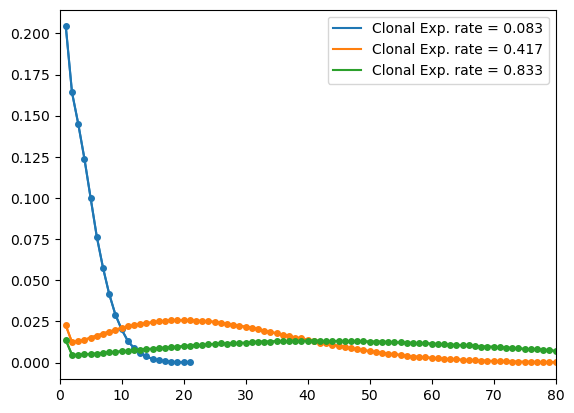

In [10]:
serie.plot(marker='o', markersize=4, color='C0')
plt.plot(serie.index, BSpline(*spline)(serie.index), '-', color='C0', label=('Clonal Exp. rate = %.3f' % (1/12)))

serie5Cl.plot(marker='o', markersize=4, color='C1')
plt.plot(serie5Cl.index, BSpline(*spline5Cl)(serie5Cl.index), '-', color='C1', label=('Clonal Exp. rate = %.3f' % (5/12)))

serie10Cl.plot(marker='o', markersize=4, color='C2')
plt.plot(serie10Cl.index, BSpline(*spline10Cl)(serie10Cl.index), '-', color='C2', label=('Clonal Exp. rate = %.3f' % (10/12)))

plt.xlim([0,80])
plt.legend()

In [25]:
splineLogit = splrep(serie.index, logit(serie.values),s=1)
splineLogit5Cl = splrep(serie5Cl.index, logit(serie5Cl.values),s=1)
splineLogit10Cl = splrep(serie10Cl.index, logit(serie10Cl.values),s=1)

In [51]:
splineLogitFunc = BSpline(*splineLogit)
splineLogitFunc5Cl = BSpline(*splineLogit5Cl)
splineLogitFunc10Cl = BSpline(*splineLogit10Cl)

In [65]:
exp_data = pd.read_csv("Data4Fig/TratioDC.csv", sep="\t")
exp_data_filtered = exp_data[(exp_data["Day"] == 11) & (exp_data["Treatment"] == "MTX")]["TratioDC"]

In [54]:
log_likelyhood = np.log(np.prod(expit(BSpline(*splineLogit)(exp_data_filtered))))
log_likelyhood5Cl = np.log(np.prod(expit(BSpline(*splineLogit5Cl)(exp_data_filtered))))
log_likelyhood10Cl = np.log(np.prod(expit(BSpline(*splineLogit10Cl)(exp_data_filtered))))

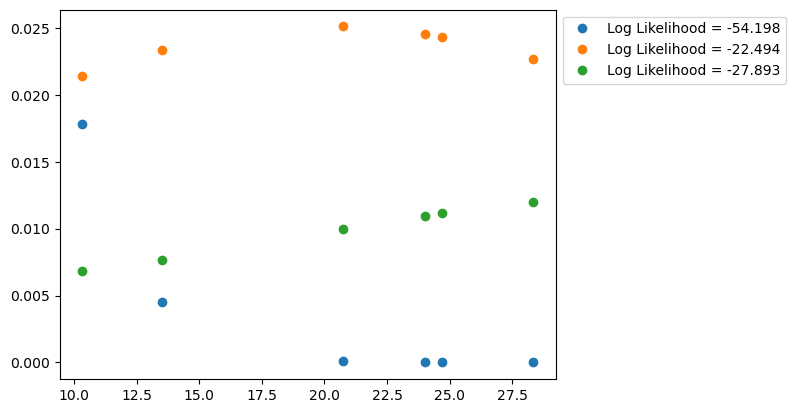

In [64]:
plt.plot(exp_data_filtered.values, expit(splineLogitFunc(exp_data_filtered)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood))
plt.plot(exp_data_filtered.values, expit(splineLogitFunc5Cl(exp_data_filtered)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood5Cl))
plt.plot(exp_data_filtered.values, expit(splineLogitFunc10Cl(exp_data_filtered)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood10Cl))
plt.legend(loc='upper left', bbox_to_anchor=(1., 1.))